# Metrics cross-check — engaging the prior art on our own data

This notebook answers the reviewer's fair question — *"why energy-per-token and not MFU / MBU /
goodput?"* — by **implementing those established metrics on our measured `.gz` telemetry** and showing
they tell the **same story** (high utilization, low compute efficiency, memory-bandwidth bound). It is
the rigorous companion to [`METHODOLOGY.md`](METHODOLOGY.md).

> ## ⚠️ Hard caveat — no cross-paper number comparison
> The metrics below are **reproduced on our own single-config measurement** (one NVIDIA L4, Granite-3.3-8B
> / Mistral-7B-v0.3, FP16, a synthetic sweep). We **do not** place our numbers beside numbers from the
> cited papers as if comparable — different hardware, models, and workloads make cross-comparison
> meaningless. We show **directional consistency** (inference is memory-bandwidth bound → low MFU, high
> MBU), which is the literature's qualitative result. The FLOPs-per-token ≈ `2·N` approximation ignores
> attention, KV-cache traffic, and kernel overhead, so MFU/MBU here are **order-of-magnitude estimates**,
> not precise efficiencies.

## Verified constants (cited, not from memory)

| Constant | Value | Source |
|---|---|---|
| L4 FP16 Tensor (dense) | **121 TFLOP/s** | NVIDIA L4 datasheet: "FP16 Tensor Core 242 teraFLOPS\*", "\* Shown with sparsity. Specifications are one-half lower without sparsity" → 242 / 2 = 121 dense ([nvidia.com/en-us/data-center/l4](https://www.nvidia.com/en-us/data-center/l4/)) |
| L4 memory bandwidth | **300 GB/s** | same datasheet ("GPU memory bandwidth 300GB/s") |
| L4 TDP | 72 W | same datasheet (matches our measured flat power) |
| FLOPs / token (fwd) | **≈ 2·N** | standard MFU accounting ([MFU/MBU explainer](https://www.zettabyte.space/blog/gpu-utilization-mfu-mbu)) |
| Bytes / param (FP16) | 2 | half precision |
| N — Granite-3.3-8B | ≈ 8.2e9 | model card: "8-billion parameter" ([RedHatAI/granite-3.3-8b-instruct](https://huggingface.co/RedHatAI/granite-3.3-8b-instruct)) |
| N — Mistral-7B-v0.3 | ≈ 7.2e9 | model card: "~7 billion parameters" ([mistralai/Mistral-7B-Instruct-v0.3](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3)) |

**Definitions used (documented):**
- **MFU** = `2·N · useful_tps / peak_FLOPs_dense` — aggregate compute throughput (useful = prefill+decode
  tokens) over dense FP16 peak.
- **MBU** = `2·N · gen_tps / (batch · peak_BW)` — in autoregressive **decode**, the weights (`2·N` bytes
  in FP16) are read **once per forward step** and amortised across the batch (≈ concurrency), so the
  per-step weight traffic is `2·N` and steps/s = `gen_tps / batch`. (Dividing by batch keeps MBU ≤ 100%;
  the un-amortised demand would exceed peak BW, which is *why* batching helps.)
- **Goodput** = useful throughput that meets an SLO. We use a **TTFT ≤ 1 s** SLO from the measured
  `ttft_seconds` ([goodput concept: arXiv:2410.14257](https://arxiv.org/abs/2410.14257)).
- **Energy-per-token** = our KPI itself (`J/1k ÷ 1000`) — the metric proposed by
  [arXiv:2603.20224](https://arxiv.org/abs/2603.20224).

In [1]:
import gzip, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline

# Constants (see table above; all cited).
PEAK_FP16_DENSE = 121e12      # FLOP/s  (datasheet 242 TFLOPS FP16 w/ sparsity -> 121 dense)
PEAK_BW         = 300e9       # bytes/s (datasheet GPU memory bandwidth 300 GB/s)
BYTES_PER_PARAM = 2           # FP16
N_PARAMS = {"Granite-3.3-8B": 8.2e9, "Mistral-7B-v0.3": 7.2e9}
SOURCES  = {"Granite-3.3-8B": "sweep_telemetry_raw.jsonl.gz",
            "Mistral-7B-v0.3": "sweep_telemetry_modelb.jsonl.gz"}
TARGETS=(1,2,4,8,16,32); TRIM_S=15.0; TTFT_SLO_S=1.0

def data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        d = base/"case-studies"/"granite-3.3-8b-l4"/"data"
        if d.exists(): return d
    raise FileNotFoundError("could not locate case-study data/ from cwd")
DATA = data_dir(); print("data dir:", DATA)

def phases(path):
    rows=[json.loads(l) for l in gzip.open(path,"rt")]
    rows.sort(key=lambda r:r["ts"]); cur=0; ph={}
    for r in rows:
        run=int(r["num_requests_running"])
        if run in TARGETS and run>cur: cur=run
        if cur>0: ph.setdefault(cur,[]).append(r)
    return ph

def metrics(model):
    N=N_PARAMS[model]; ph=phases(DATA/SOURCES[model]); out=[]
    for c0 in TARGETS:
        s=pd.DataFrame(ph[c0]); t0,t1=s.ts.iloc[0]/1000,s.ts.iloc[-1]/1000
        s=s[(s.ts/1000>=t0+TRIM_S)&(s.ts/1000<=t1-TRIM_S)]
        dt=(s.ts.iloc[-1]-s.ts.iloc[0])/1000
        d_use=(s.generation_tokens_total.iloc[-1]+s.prompt_tokens_total.iloc[-1])-(s.generation_tokens_total.iloc[0]+s.prompt_tokens_total.iloc[0])
        d_gen=s.generation_tokens_total.iloc[-1]-s.generation_tokens_total.iloc[0]
        useful_tps=d_use/dt; gen_tps=d_gen/dt; pw=s.power_watts.mean()
        j_power=pw/useful_tps*1000
        mfu=2*N*useful_tps/PEAK_FP16_DENSE                       # aggregate compute / dense peak
        mbu=2*N*gen_tps/(c0*PEAK_BW)                             # decode weight traffic, batch-amortised
        ttft=s.ttft_seconds[s.ttft_seconds>0]
        slo_frac=float((ttft<=TTFT_SLO_S).mean()) if len(ttft) else float("nan")
        out.append(dict(concurrency=c0, useful_tps=round(useful_tps,1), gen_tps=round(gen_tps,1),
                        J_per_1k=round(j_power), J_per_token=round(j_power/1000,3),
                        MFU_pct=round(mfu*100,2), MBU_pct=round(mbu*100,1),
                        TTFT_p95_s=round(float(ttft.quantile(0.95)),3) if len(ttft) else None,
                        goodput_tps=round(useful_tps*slo_frac,1)))
    return pd.DataFrame(out)

tabs={m: metrics(m) for m in N_PARAMS}
print("\nGranite-3.3-8B"); display(tabs["Granite-3.3-8B"])
print("Mistral-7B-v0.3"); display(tabs["Mistral-7B-v0.3"])

data dir: /Users/oscar/Documents/GitHub/gpu-efficiency-streaming/case-studies/granite-3.3-8b-l4/data

Granite-3.3-8B


,concurrency,useful_tps,gen_tps,J_per_1k,J_per_token,MFU_pct,MBU_pct,TTFT_p95_s,goodput_tps
0,1,17.2,15.5,4192,4.192,0.23,84.5,0.463,17.2
1,2,33.1,29.8,2173,2.173,0.45,81.5,0.149,33.1
2,4,66.1,59.5,1089,1.089,0.90,81.4,0.148,66.1
3,8,130.5,117.7,551,0.551,1.77,80.4,0.169,130.5
4,16,256.9,231.8,280,0.280,3.48,79.2,0.183,256.9
5,32,466.1,414.8,154,0.154,6.32,70.9,0.194,466.1


Mistral-7B-v0.3


,concurrency,useful_tps,gen_tps,J_per_1k,J_per_token,MFU_pct,MBU_pct,TTFT_p95_s,goodput_tps
0,1,19.9,17.8,3552,3.552,0.24,85.6,0.072,19.9
1,2,38.4,34.3,1876,1.876,0.46,82.4,0.097,38.4
2,4,76.1,68.2,944,0.944,0.91,81.8,0.117,76.1
3,8,150.4,134.7,478,0.478,1.79,80.8,0.145,150.4
4,16,296.6,265.7,243,0.243,3.53,79.7,0.157,296.6
5,32,531.2,483.0,135,0.135,6.32,72.4,0.162,531.2


## MFU is low, MBU is high → memory-bandwidth bound (the literature's result, on our data)

Across the sweep, **MFU stays in the single-digit %** (far below the ~50 % achievable on compute-bound
training) while **MBU is high (~70–85 %)**. That gap is the signature of **memory-bandwidth-bound
inference** — exactly the qualitative result in the MFU/MBU literature. Batching (rising concurrency)
*raises* MFU (better compute use) while MBU stays high, which is why batching is the lever the efficiency
frontier rewards. (Numbers are our-data estimates under the `2·N` approximation — not comparable to any
paper's hardware.)

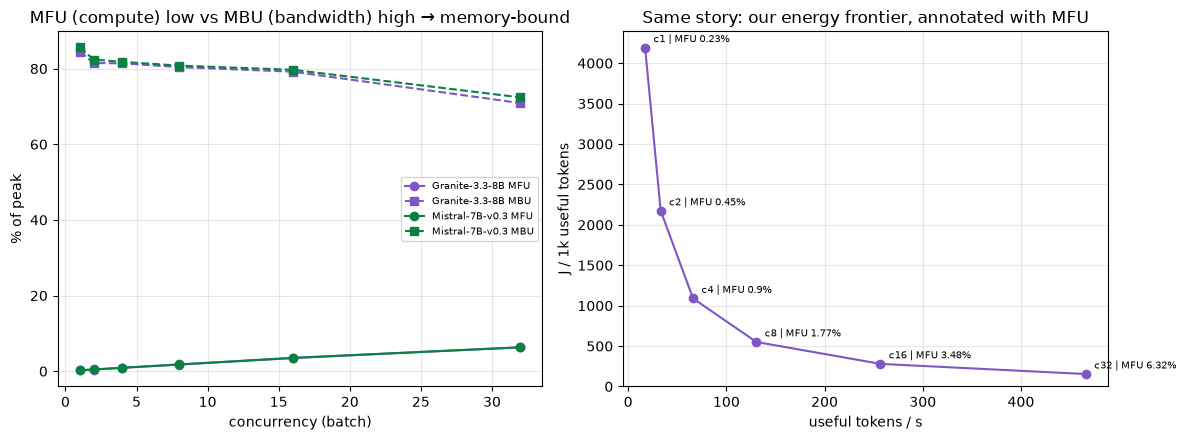

MFU range (Granite): 0.23% -> 6.32%   MBU range: 70.9% -> 84.5%


In [2]:
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
for m,clr in [("Granite-3.3-8B","#7e57c2"),("Mistral-7B-v0.3","#0b8043")]:
    t=tabs[m]
    ax[0].plot(t.concurrency,t.MFU_pct,"-o",color=clr,label=f"{m} MFU")
    ax[0].plot(t.concurrency,t.MBU_pct,"--s",color=clr,label=f"{m} MBU")
ax[0].set_xlabel("concurrency (batch)"); ax[0].set_ylabel("% of peak")
ax[0].set_title("MFU (compute) low vs MBU (bandwidth) high → memory-bound"); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=7)
t=tabs["Granite-3.3-8B"]
ax[1].plot(t.useful_tps,t.J_per_1k,"-o",color="#7e57c2")
for _,r in t.iterrows(): ax[1].annotate(f"c{int(r.concurrency)} | MFU {r.MFU_pct}%",(r.useful_tps,r.J_per_1k),textcoords="offset points",xytext=(6,4),fontsize=7)
ax[1].set_xlabel("useful tokens / s"); ax[1].set_ylabel("J / 1k useful tokens"); ax[1].set_ylim(bottom=0)
ax[1].set_title("Same story: our energy frontier, annotated with MFU"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("MFU range (Granite): %.2f%% -> %.2f%%   MBU range: %.1f%% -> %.1f%%" % (
      t.MFU_pct.min(),t.MFU_pct.max(),t.MBU_pct.min(),t.MBU_pct.max()))

## Our KPI *is* energy-per-token

`joules_per_1k_tokens / 1000` is energy-per-(useful)-token — the metric advocated by
[arXiv:2603.20224](https://arxiv.org/abs/2603.20224). We compute it directly from our data; it is the
governed signal the streaming pipeline emits. Below, energy-per-token vs MFU shows the same monotonic
story: as batching raises compute efficiency (MFU), energy-per-token falls.

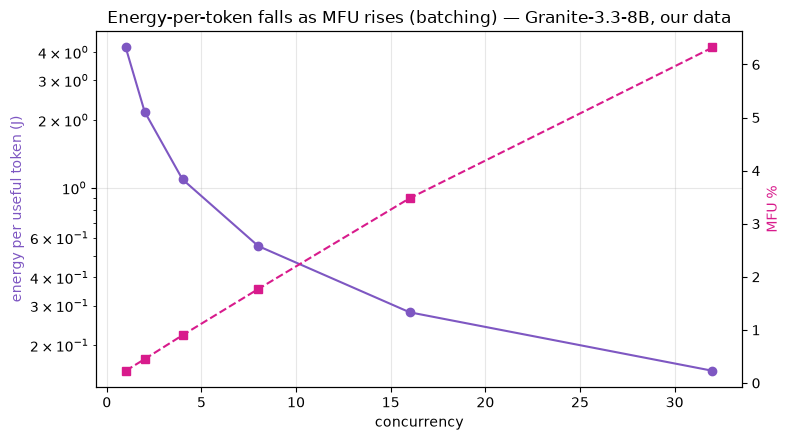

In [3]:
t=tabs["Granite-3.3-8B"]
fig,ax1=plt.subplots(figsize=(8,4.5))
ax1.plot(t.concurrency,t.J_per_token,"-o",color="#7e57c2"); ax1.set_xlabel("concurrency")
ax1.set_ylabel("energy per useful token (J)",color="#7e57c2"); ax1.set_yscale("log"); ax1.grid(alpha=0.3)
ax2=ax1.twinx(); ax2.plot(t.concurrency,t.MFU_pct,"--s",color="#d81b8c"); ax2.set_ylabel("MFU %",color="#d81b8c")
plt.title("Energy-per-token falls as MFU rises (batching) — Granite-3.3-8B, our data")
plt.tight_layout(); plt.show()

## Goodput (TTFT-SLO) on our data

Using the measured `ttft_seconds` and a **TTFT ≤ 1 s** SLO, goodput ≈ measured throughput at every
tested concurrency: TTFT stayed well under 1 s (p95 below), so the SLO is met. This is expected at
concurrency ≤ 32 on this GPU; goodput would diverge from raw throughput at higher load where TTFT
breaches the SLO. (`inter_token_latency_s` was not emitted by the bridge in this capture, so an
ITL-based goodput is left as future work — stated honestly.)

In [4]:
gp=tabs["Granite-3.3-8B"][["concurrency","useful_tps","goodput_tps","TTFT_p95_s"]]
display(gp)
print("TTFT p95 stays under the 1s SLO at all tested concurrencies -> SLO-goodput ~ throughput here.")

,concurrency,useful_tps,goodput_tps,TTFT_p95_s
0,1,17.2,17.2,0.463
1,2,33.1,33.1,0.149
2,4,66.1,66.1,0.148
3,8,130.5,130.5,0.169
4,16,256.9,256.9,0.183
5,32,466.1,466.1,0.194


TTFT p95 stays under the 1s SLO at all tested concurrencies -> SLO-goodput ~ throughput here.


## Conclusion

Implemented on our own measured telemetry, **MFU (single-digit %)**, **MBU (~70–85 %)**,
**TTFT-goodput**, and **energy-per-token** all tell one story: inference on this L4 is
**memory-bandwidth bound**, utilization is a poor cost signal, and batching is the efficiency lever —
the established qualitative result. We engage the prior art by **reproducing its metrics on our data**,
not by comparing our numbers to theirs (different hardware/workload).

**Citations:** MFU/MBU concept — [zettabyte](https://www.zettabyte.space/blog/gpu-utilization-mfu-mbu) ·
goodput — [arXiv:2410.14257](https://arxiv.org/abs/2410.14257) · energy-per-token —
[arXiv:2603.20224](https://arxiv.org/abs/2603.20224) · L4 peak FP16 (dense) + bandwidth —
[NVIDIA L4 datasheet](https://www.nvidia.com/en-us/data-center/l4/).

*Trademarks: NVIDIA® and L4 are trademarks of NVIDIA Corporation; IBM® and Granite of IBM Corp.
Independent, unaffiliated project.*